# 02 — Exploratory Data Analysis
**Objectif :** comprendre la structure du dataset, identifier les variables prédictives du défaut, repérer les features à drop avant modélisation.

**Sortie :** un dataset nettoyé `freddie_mac_features.parquet` prêt pour le notebook 03 (feature engineering).

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = os.path.join('..', 'data', 'freddie_mac_clean.parquet')
df = pd.read_parquet(DATA_PATH)

print(f"Dataset : {df.shape[0]:,} prêts × {df.shape[1]} variables")
print(f"Taux de défaut global : {df['default'].mean():.2%}")
df.head(10)

Dataset : 100,000 prêts × 38 variables
Taux de défaut global : 5.57%


,credit_score,first_payment_date,first_time_homebuyer_flag,maturity_date,msa,mip,units,occupancy_status,ocltv,dti,original_upb,oltv,original_interest_rate,channel,ppm_flag,amortization_type,property_state,property_type,postal_code,loan_sequence_number,loan_purpose,original_loan_term,number_of_borrowers,seller_name,servicer_name,super_conforming_flag,pre_harp_loan_sequence_number,program_indicator,harp_indicator,property_valuation_method,interest_only_indicator,mi_cancellation_indicator,max_delinquency,months_delinquent,ever_modified,zero_balance_code,loan_age_months,default
0,809.0,201705,N,204704,None,0,1,P,75.0,38.0,195000,75.0,4.250,R,N,FRM,PA,SF,17900,F17Q10000002,N,360,01,Other sellers,SPECIALIZED LOAN SERVICING...,None,None,9,None,7,N,7,0.0,0,False,01,56,0
1,702.0,201703,N,203202,None,0,1,P,80.0,36.0,187000,76.0,3.000,R,N,FRM,KY,SF,42000,F17Q10000017,N,180,02,Other sellers,Other servicers,None,None,9,None,7,N,7,0.0,0,False,None,103,0
2,792.0,201703,N,204702,None,0,1,S,60.0,36.0,87000,60.0,3.375,R,N,FRM,MI,SF,48700,F17Q10000064,N,360,02,Other sellers,Other servicers,None,None,9,None,7,N,7,0.0,0,False,01,60,0
3,776.0,201703,N,204702,None,0,1,S,80.0,18.0,106000,80.0,4.250,R,N,FRM,NY,SF,12700,F17Q10000065,P,360,02,Other sellers,Other servicers,None,None,9,None,7,N,7,0.0,0,False,01,41,0
4,790.0,201703,N,204702,41620,0,1,I,75.0,42.0,75000,75.0,4.250,C,N,FRM,UT,CO,84100,F17Q10000073,C,360,01,Other sellers,"PNC BANK, NA",None,None,9,None,7,N,7,1.0,1,False,None,103,0
5,726.0,201703,N,204702,39820,0,1,P,80.0,22.0,245000,80.0,3.875,R,N,FRM,CA,SF,96000,F17Q10000094,C,360,02,Other sellers,Other servicers,None,None,9,None,7,N,7,0.0,0,False,None,103,0
6,687.0,201703,N,204702,46520,0,1,P,80.0,45.0,619000,75.0,3.875,R,N,FRM,HI,PU,96700,F17Q10000176,C,360,02,Other sellers,Other servicers,None,None,9,None,7,N,7,8.0,12,False,01,56,1
7,766.0,201703,N,204702,None,0,1,P,72.0,27.0,185000,72.0,3.875,R,N,FRM,CO,SF,81200,F17Q10000300,C,360,02,Other sellers,U.S. BANK N.A.,None,None,9,None,7,N,7,0.0,0,False,01,32,0
8,794.0,201703,N,204702,46520,0,1,P,60.0,19.0,258000,60.0,3.375,R,N,FRM,HI,CO,96800,F17Q10000330,C,360,01,Other sellers,U.S. BANK N.A.,None,None,9,None,7,N,7,0.0,0,False,None,103,0
9,804.0,201703,N,204702,None,0,1,P,80.0,32.0,132000,80.0,3.500,R,N,FRM,KS,SF,67600,F17Q10000408,P,360,02,Other sellers,Other servicers,None,None,9,None,7,N,7,0.0,0,False,01,38,0


## 1. Types et valeurs manquantes

In [2]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_%': (df.isnull().mean() * 100).round(2),
    'n_unique': df.nunique(),
})
summary.sort_values('missing_%', ascending=False)

,dtype,missing_%,n_unique
harp_indicator,object,97.68,1
pre_harp_loan_sequence_number,object,97.68,2315
super_conforming_flag,object,96.58,1
zero_balance_code,object,23.14,7
msa,object,10.57,442
dti,float64,2.32,50
credit_score,float64,0.02,304
number_of_borrowers,object,0.00,5
seller_name,object,0.00,35
servicer_name,object,0.00,29


## 2. Variables constantes ou quasi-constantes (à drop)

In [3]:
# Une variable avec 1 seule valeur unique n'apporte aucune information
constant_cols = summary[summary['n_unique'] <= 1].index.tolist()
print(f"Variables constantes : {constant_cols}")

# Quasi-constantes : >99% d'une seule valeur
quasi_constant = []
for col in df.columns:
    if df[col].dtype == 'object' or df[col].nunique() < 10:
        top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
        if top_freq > 0.99:
            quasi_constant.append((col, round(top_freq, 4)))
print(f"\nQuasi-constantes (>99% d'une seule valeur) :")
for c, f in quasi_constant:
    print(f"  {c}: {f*100:.2f}%")

Variables constantes : ['ppm_flag', 'amortization_type', 'super_conforming_flag', 'harp_indicator', 'interest_only_indicator']

Quasi-constantes (>99% d'une seule valeur) :
  ppm_flag: 100.00%
  amortization_type: 100.00%
  interest_only_indicator: 100.00%


## 3. Distribution des features numériques clés

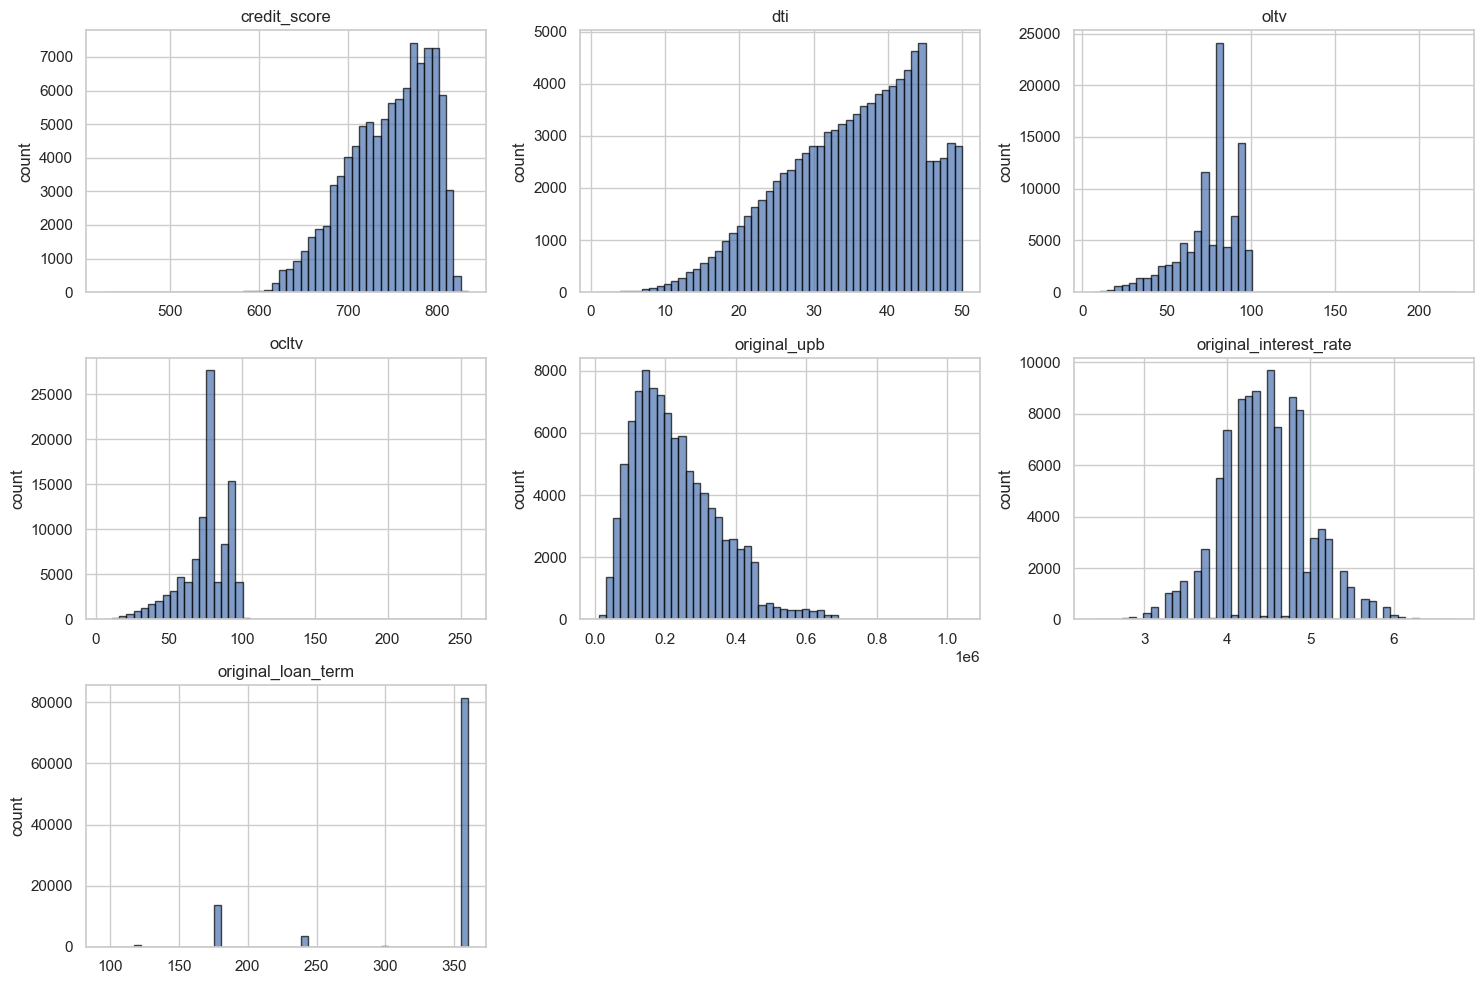

,credit_score,dti,oltv,ocltv,original_upb,original_interest_rate,original_loan_term
count,99978.00,97681.00,99999.00,99999.00,100000.00,100000.00,100000.00
mean,745.47,35.49,75.44,75.81,230843.62,4.46,329.24
std,46.65,9.36,17.14,17.11,121140.06,0.53,66.17
min,427.00,1.00,6.00,6.00,11000.00,2.38,96.00
25%,712.00,29.00,68.00,68.00,139000.00,4.12,360.00
50%,753.00,37.00,80.00,80.00,207000.00,4.50,360.00
75%,784.00,43.00,90.00,90.00,304000.00,4.88,360.00
max,834.00,50.00,222.00,255.00,1041000.00,6.75,360.00


In [4]:
NUMERIC_FEATURES = ['credit_score', 'dti', 'oltv', 'ocltv',
                    'original_upb', 'original_interest_rate', 'original_loan_term']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, NUMERIC_FEATURES):
    df[col].dropna().hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_ylabel('count')
for ax in axes.flat[len(NUMERIC_FEATURES):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

df[NUMERIC_FEATURES].describe().round(2)

## 4. Taux de défaut par feature numérique (binning)

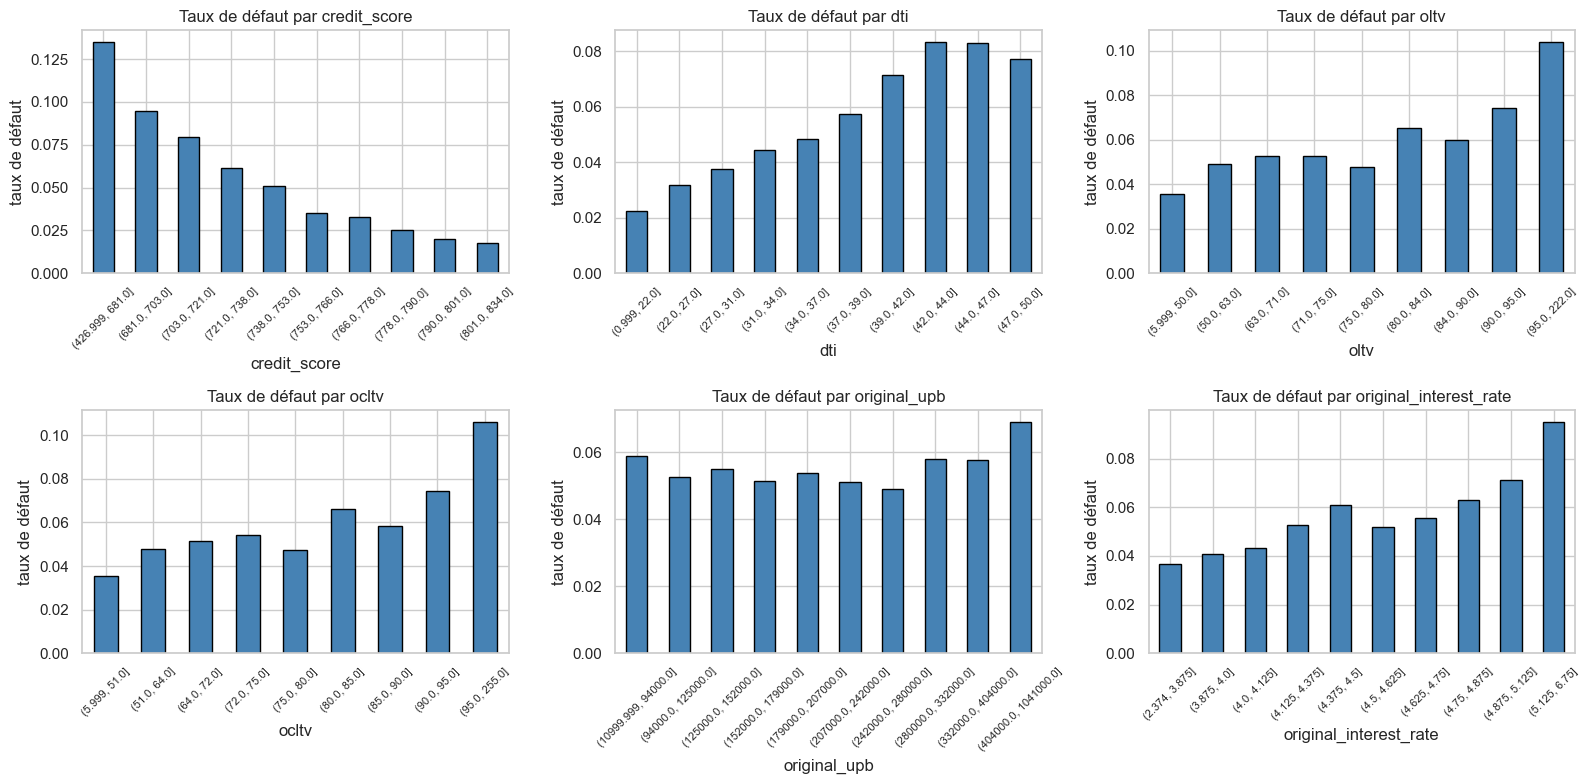

In [5]:
def default_rate_by_bin(df, col, bins=10):
    """Découpe `col` en quantiles et calcule le taux de défaut par bin."""
    try:
        binned = pd.qcut(df[col], q=bins, duplicates='drop')
    except ValueError:
        binned = pd.cut(df[col], bins=bins)
    return df.groupby(binned, observed=True)['default'].agg(['mean', 'count'])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, ['credit_score', 'dti', 'oltv', 'ocltv', 'original_upb', 'original_interest_rate']):
    stats = default_rate_by_bin(df, col, bins=10)
    stats['mean'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Taux de défaut par {col}')
    ax.set_ylabel('taux de défaut')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

## 5. Taux de défaut par feature catégorielle

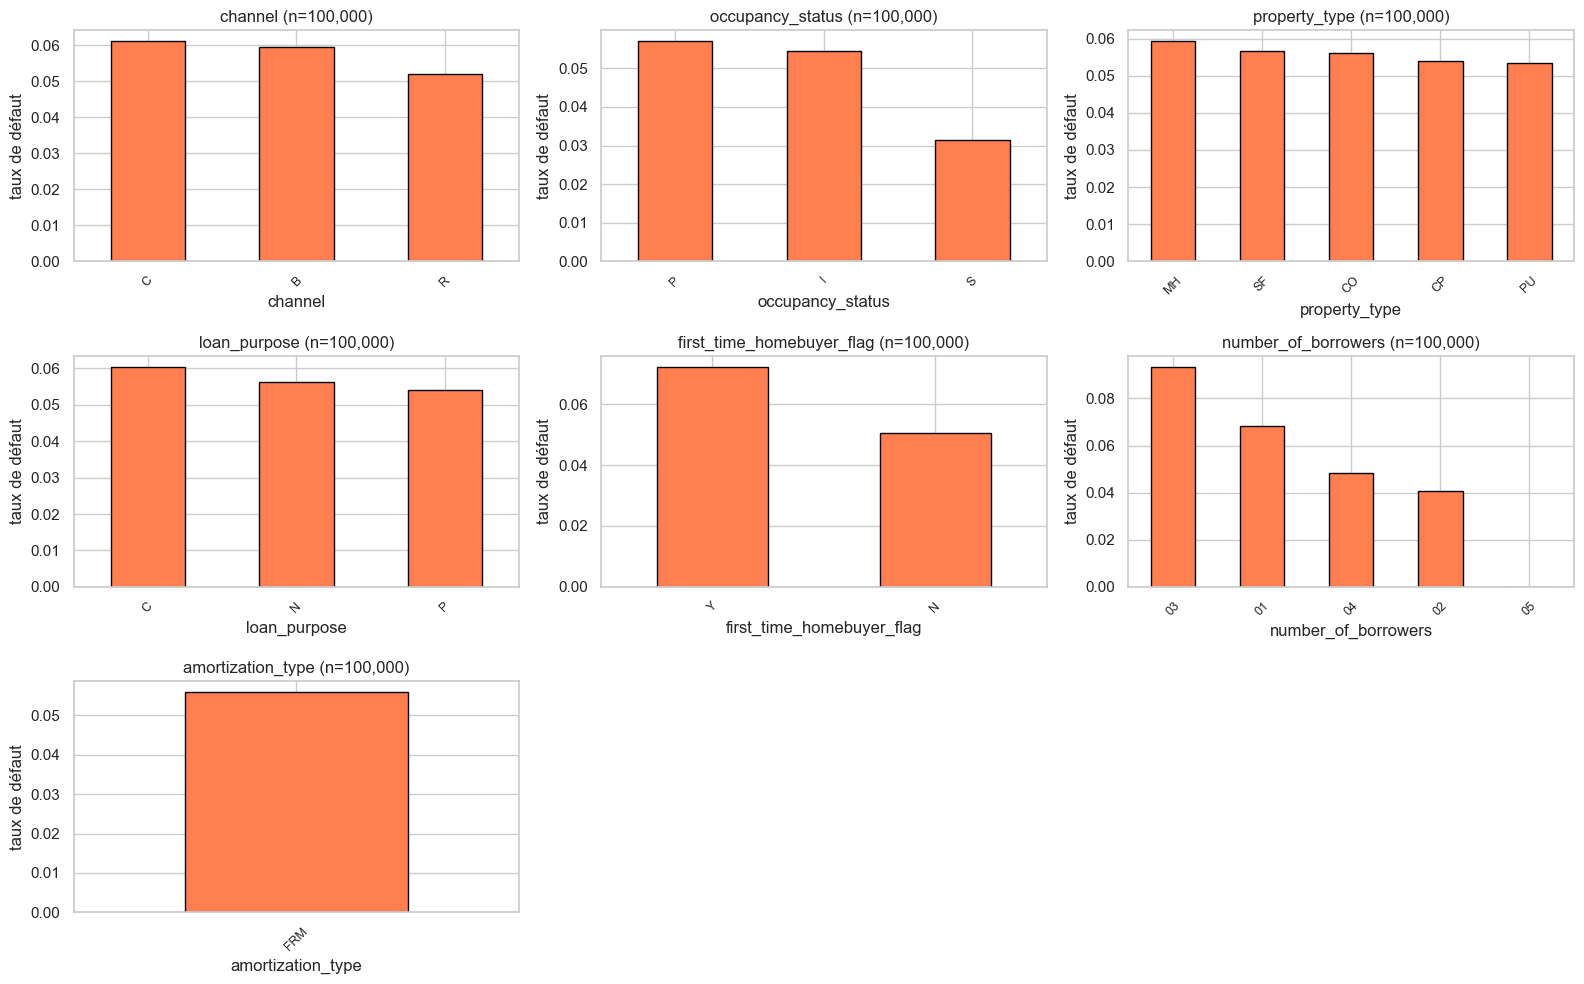

In [6]:
CATEGORICAL = ['channel', 'occupancy_status', 'property_type', 'loan_purpose',
               'first_time_homebuyer_flag', 'number_of_borrowers', 'amortization_type']

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for ax, col in zip(axes.flat, CATEGORICAL):
    stats = df.groupby(col, observed=True)['default'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    stats['mean'].plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_title(f'{col} (n={stats["count"].sum():,})')
    ax.set_ylabel('taux de défaut')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
for ax in axes.flat[len(CATEGORICAL):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Taux de défaut par état (top 15 risque)

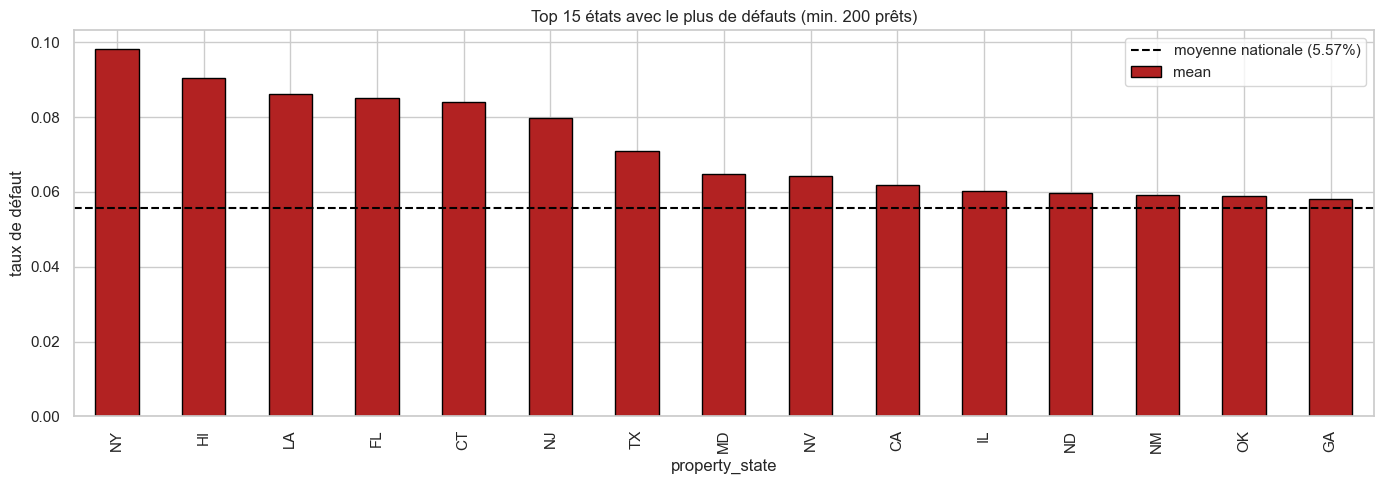

,mean,count
property_state,,
NY,0.098253,3206
HI,0.090343,321
LA,0.086154,975
FL,0.085076,6935
CT,0.084081,892
NJ,0.079643,2574
TX,0.070800,8178
MD,0.064699,1762
NV,0.064179,1340


In [7]:
state_stats = (df.groupby('property_state')['default']
               .agg(['mean', 'count'])
               .query('count >= 200')
               .sort_values('mean', ascending=False))

fig, ax = plt.subplots(figsize=(14, 5))
state_stats.head(15)['mean'].plot(kind='bar', ax=ax, color='firebrick', edgecolor='black')
ax.set_title('Top 15 états avec le plus de défauts (min. 200 prêts)')
ax.set_ylabel('taux de défaut')
ax.axhline(df['default'].mean(), color='black', linestyle='--', label=f"moyenne nationale ({df['default'].mean():.2%})")
ax.legend()
plt.tight_layout()
plt.show()

state_stats.head(15)

## 7. Corrélations entre features numériques

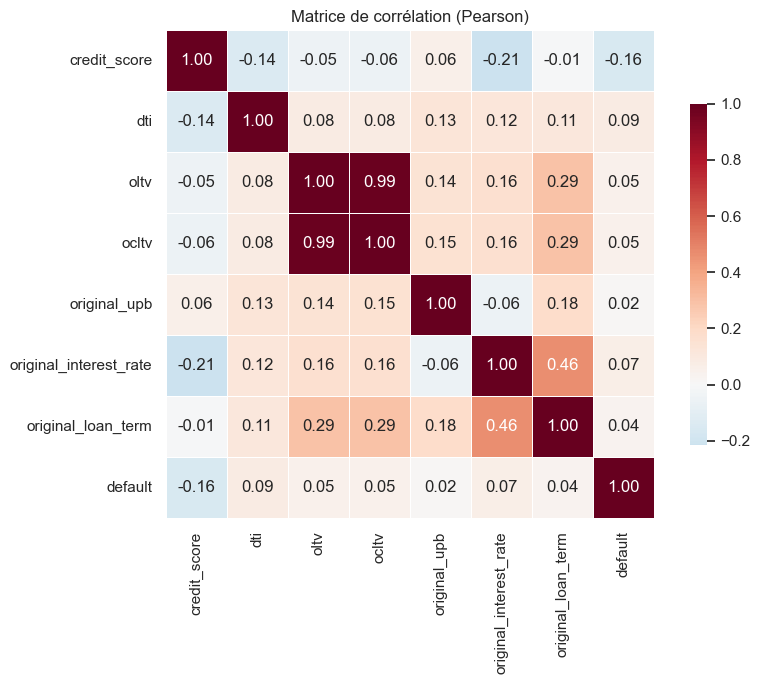


Corrélations avec default (triées) :
credit_score             -0.160
dti                       0.088
original_interest_rate    0.067
ocltv                     0.054
oltv                      0.051
original_loan_term        0.036
original_upb              0.015
Name: default, dtype: float64


In [8]:
corr_features = NUMERIC_FEATURES + ['default']
corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Matrice de corrélation (Pearson)')
plt.tight_layout()
plt.show()

print("\nCorrélations avec default (triées) :")
print(corr_matrix['default'].drop('default').sort_values(key=abs, ascending=False).round(3))

## 8. Décision : variables à drop pour la modélisation

**À drop systématiquement :**
- Constantes / quasi-constantes (identifiées en section 2)
- `loan_sequence_number` → identifiant, pas de pouvoir prédictif
- `seller_name`, `servicer_name` → trop de modalités, risque de leakage
- `pre_harp_loan_sequence_number` → 97% manquant
- `harp_indicator` → 97% manquant
- Variables construites à partir de la performance (`max_delinquency`, `months_delinquent`, `zero_balance_code`, `ever_modified`, `loan_age_months`) → **leakage** : elles servent à définir la cible

**À garder :**
- Toutes les variables numériques d'origination
- Variables catégorielles avec impact visible sur le défaut
- `property_state` (impact géographique fort)

In [9]:
LEAKAGE = ['max_delinquency', 'months_delinquent', 'ever_modified',
           'zero_balance_code', 'loan_age_months']
IDS = ['loan_sequence_number', 'pre_harp_loan_sequence_number']
HIGH_MISSING = ['harp_indicator', 'super_conforming_flag']
TEXT_HEAVY = ['seller_name', 'servicer_name']
CONSTANTS = constant_cols + [c for c, _ in quasi_constant]

TO_DROP = list(set(LEAKAGE + IDS + HIGH_MISSING + TEXT_HEAVY + CONSTANTS))
print(f"Variables à drop ({len(TO_DROP)}) :")
for c in sorted(TO_DROP):
    print(f"  {c}")

df_features = df.drop(columns=[c for c in TO_DROP if c in df.columns])
print(f"\nDataset features : {df_features.shape[0]:,} prêts × {df_features.shape[1]} variables")
print(f"Cible conservée : 'default' (taux = {df_features['default'].mean():.2%})")

Variables à drop (14) :
  amortization_type
  ever_modified
  harp_indicator
  interest_only_indicator
  loan_age_months
  loan_sequence_number
  max_delinquency
  months_delinquent
  ppm_flag
  pre_harp_loan_sequence_number
  seller_name
  servicer_name
  super_conforming_flag
  zero_balance_code

Dataset features : 100,000 prêts × 24 variables
Cible conservée : 'default' (taux = 5.57%)


## 9. Sauvegarde

In [10]:
out_path = os.path.join('..', 'data', 'freddie_mac_features.parquet')
df_features.to_parquet(out_path, index=False)
print(f"Sauvegardé : {out_path}")
print(f"Colonnes finales :")
for c in df_features.columns:
    print(f"  {c}")

Sauvegardé : ../data/freddie_mac_features.parquet
Colonnes finales :
  credit_score
  first_payment_date
  first_time_homebuyer_flag
  maturity_date
  msa
  mip
  units
  occupancy_status
  ocltv
  dti
  original_upb
  oltv
  original_interest_rate
  channel
  property_state
  property_type
  postal_code
  loan_purpose
  original_loan_term
  number_of_borrowers
  program_indicator
  property_valuation_method
  mi_cancellation_indicator
  default
